# AI-Powered Support Ticket Triage & Routing Engine
### Benchmarked on the real, public **BANKING77** dataset

**Jordan Shamukiga — Data Analyst · Business Analyst · Data Scientist**

This notebook trains a traditional ML baseline on real customer-support messages and
sets up an honest head-to-head against an LLM triage engine.

**Two honesty notes that shape everything below:**
1. **The data is real.** BANKING77 — 13,083 real online-banking customer messages, 77
   intent labels, PolyAI, CC-BY-4.0. Nothing is synthetic.
2. **BANKING77 labels only the *intent*.** There is no urgency/sentiment/entity ground
   truth, so the *scored* benchmark is intent classification. The LLM's other outputs are
   shown as capabilities, not graded against labels that don't exist. And because this
   build has no `ANTHROPIC_API_KEY`, the LLM's intent score is left blank rather than
   faked — the LIVE path is wired to run the moment a key is present.

In [1]:
import sys, os, json
sys.path.insert(0, os.path.abspath('..')) if os.path.basename(os.getcwd())=='notebooks' else sys.path.insert(0, os.path.abspath('.'))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix

from src.data_loader import (load_dataset, intent_labels, HIGH_STAKES,
                             TEXT_COL, LABEL_COL, DATASET_NAME, DATASET_SOURCE, DATASET_LICENSE)
from src.ml_baseline import build_baseline, make_text
from src.evaluation import score
from src.business_impact import automation_summary, roi_model, high_stakes_leakage
from src.llm_classifier import is_live_mode, classify_ticket, build_system_prompt, estimate_live_cost

INK="#2c3e50"; ACCENT="#8e44ad"; ML="#f7931e"; GOOD="#27ae60"; BAD="#c0392b"
plt.rcParams.update({"figure.dpi":110,"font.size":10,"axes.spines.top":False,"axes.spines.right":False})
VIZ="../visualizations" if os.path.basename(os.getcwd())=="notebooks" else "visualizations"
os.makedirs(VIZ, exist_ok=True)
print("LIVE mode:", is_live_mode())

LIVE mode: False


## 1. The real dataset

`src/data_loader.py` downloads BANKING77 from PolyAI's GitHub, caches it under `data/raw/`,
and cleans it. Let's load it and look at exactly what we have.

In [2]:
train, test = load_dataset()
labels = intent_labels(train)
print(f"Dataset : {DATASET_NAME}  (license {DATASET_LICENSE})")
print(f"Source  : {DATASET_SOURCE}")
print(f"Train   : {len(train):,} rows   Test: {len(test):,} rows   Intents: {len(labels)}")
print(f"Columns : {list(train.columns)}\n")
train.sample(6, random_state=1)

Dataset : BANKING77  (license CC-BY-4.0)
Source  : https://github.com/PolyAI-LDN/task-specific-datasets
Train   : 10,003 rows   Test: 3,080 rows   Intents: 77
Columns : ['text', 'intent']



,text,intent
7872,I need more physical cards.,getting_spare_card
1520,Someone stole my wallet with my card in it whi...,lost_or_stolen_card
6319,I was charged for the same thing twice,transaction_charged_twice
5197,I made a purchase earlier today but it is stil...,pending_card_payment
9019,Will there be a cost if I exchange currency?,exchange_charge
4397,Are there any restrictions for the disposable ...,disposable_card_limits


## 2. Exploratory analysis — class distribution & message length

Train per-intent: min=35  max=187  median=127
Test is balanced at 40 messages/intent

5 most common intents:
 intent
card_payment_fee_charged                            187
direct_debit_payment_not_recognised                 182
balance_not_updated_after_cheque_or_cash_deposit    181
wrong_amount_of_cash_received                       180
cash_withdrawal_charge                              177


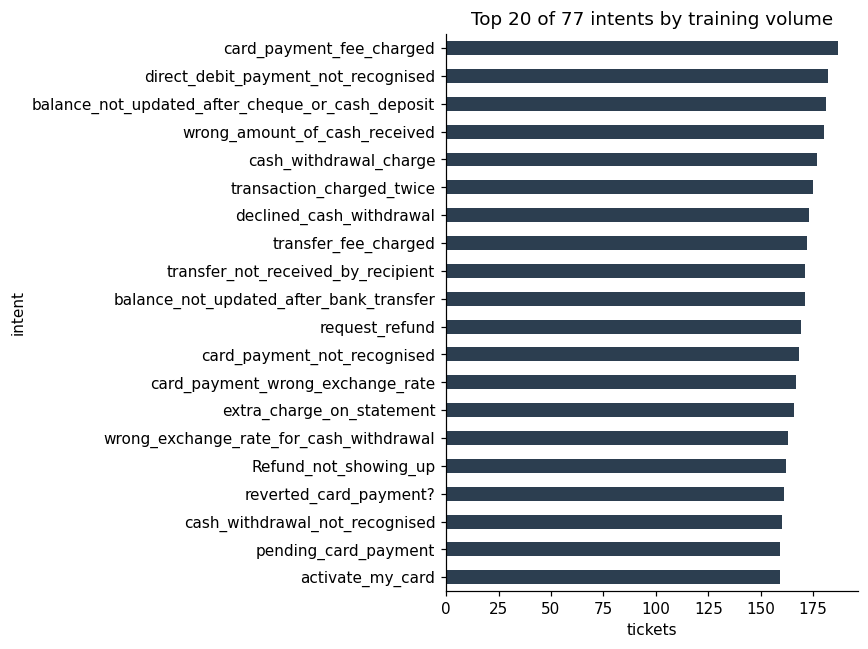

In [3]:
vc = train[LABEL_COL].value_counts()
print(f"Train per-intent: min={vc.min()}  max={vc.max()}  median={vc.median():.0f}")
print(f"Test is balanced at {test[LABEL_COL].value_counts().mode().iloc[0]} messages/intent\n")
print("5 most common intents:\n", vc.head().to_string())

fig, ax = plt.subplots(figsize=(8,6))
vc.head(20).iloc[::-1].plot.barh(ax=ax, color=INK)
ax.set_title(f"Top 20 of {len(labels)} intents by training volume"); ax.set_xlabel("tickets")
plt.tight_layout(); plt.savefig(f"{VIZ}/01_intent_distribution.png"); plt.show()

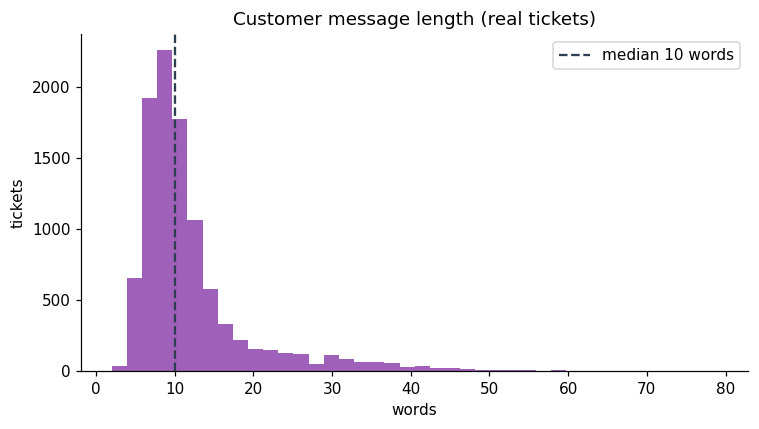

Messages are short: median 10 words, range 2–79.


In [4]:
wlen = train[TEXT_COL].str.split().str.len()
fig, ax = plt.subplots(figsize=(7,4))
ax.hist(wlen, bins=40, color=ACCENT, alpha=.85)
ax.axvline(wlen.median(), color=INK, ls="--", label=f"median {wlen.median():.0f} words")
ax.set_title("Customer message length (real tickets)"); ax.set_xlabel("words"); ax.set_ylabel("tickets"); ax.legend()
plt.tight_layout(); plt.savefig(f"{VIZ}/02_text_length_distribution.png"); plt.show()
print(f"Messages are short: median {wlen.median():.0f} words, range {wlen.min()}–{wlen.max()}.")

## 3. Data quality & cleaning decisions

BANKING77 is unusually clean. The point of this cell is to *show* that rather than assert it,
and to be explicit about the (small) cleaning actually applied.

In [5]:
raw_train = pd.read_csv(("../" if os.path.basename(os.getcwd())=="notebooks" else "")+"data/raw/banking77_train.csv")
print("nulls:", raw_train.isna().sum().to_dict())
print("exact duplicate rows:", int(raw_train.duplicated().sum()))
print("texts mapped to >1 intent:", int((raw_train.groupby('text')['category'].nunique()>1).sum()))
print("rows with stray leading/trailing whitespace:", int((raw_train['text']!=raw_train['text'].str.strip()).sum()))
overlap = set(raw_train['text']) & set(pd.read_csv(("../" if os.path.basename(os.getcwd())=="notebooks" else "")+"data/raw/banking77_test.csv")['text'])
print("train/test identical-text overlap (leakage):", len(overlap))
print("\nCleaning applied: strip whitespace, drop empties, rename columns to (text, intent).")
print("No fields invented — there is no urgency/sentiment/entity ground truth to add.")

nulls: {'text': 0, 'category': 0}
exact duplicate rows: 0
texts mapped to >1 intent: 0
rows with stray leading/trailing whitespace: 9
train/test identical-text overlap (leakage): 0

Cleaning applied: strip whitespace, drop empties, rename columns to (text, intent).
No fields invented — there is no urgency/sentiment/entity ground truth to add.


## 4. Traditional ML baseline — TF-IDF + Logistic Regression

The pre-LLM standard and the control in the benchmark. It predicts intent and nothing else.

In [6]:
pipe = build_baseline()
pipe.fit(make_text(train), train[LABEL_COL])
proba = pipe.predict_proba(make_text(test))
classes = list(pipe.named_steps['clf'].classes_)
pred = np.array([classes[i] for i in proba.argmax(1)])
conf = proba.max(1)
y = test[LABEL_COL].to_numpy()
correct = pred == y

base = score(y, pred, labels)
base["mean_confidence"] = round(float(conf.mean()),4)
print("REAL results on the held-out test set (n=3,080, 77 intents):")
print(f"  accuracy    : {base['accuracy']:.4f}")
print(f"  macro-F1    : {base['macro_f1']:.4f}")
print(f"  weighted-F1 : {base['weighted_f1']:.4f}")
print(f"  mean conf   : {base['mean_confidence']:.4f}")

REAL results on the held-out test set (n=3,080, 77 intents):
  accuracy    : 0.8477
  macro-F1    : 0.8476
  weighted-F1 : 0.8476
  mean conf   : 0.6783


## 5. Where the baseline fails — the real finding

The ~15% error rate is **not** spread evenly. It piles up in clusters of intents that are
near-synonyms even to a human. This is the analytically interesting part of the whole project.

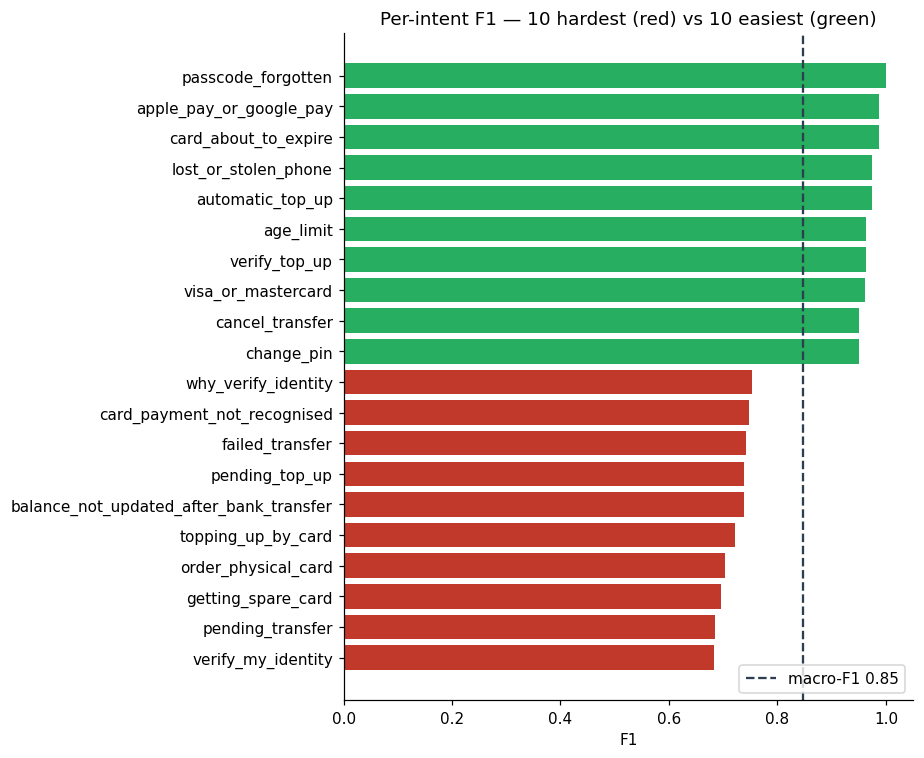

In [7]:
f1 = pd.Series({k:v['f1'] for k,v in base['per_class'].items()}).sort_values()
worst, best = f1.head(10), f1.tail(10)
fig, ax = plt.subplots(figsize=(8.5,7))
sel = pd.concat([worst,best]); colors=[BAD]*len(worst)+[GOOD]*len(best)
ax.barh(sel.index, sel.values, color=colors)
ax.axvline(base['macro_f1'], color=INK, ls='--', label=f"macro-F1 {base['macro_f1']:.2f}")
ax.set_title("Per-intent F1 — 10 hardest (red) vs 10 easiest (green)"); ax.set_xlabel("F1"); ax.legend(loc="lower right")
plt.tight_layout(); plt.savefig(f"{VIZ}/04_baseline_per_intent_f1.png"); plt.show()

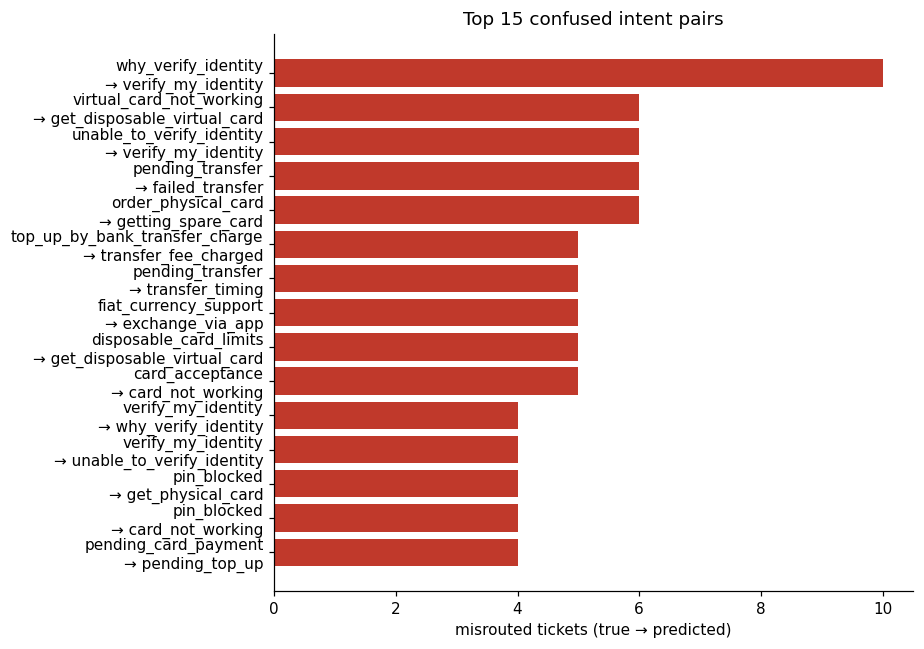

Most-confused pair: why_verify_identity -> verify_my_identity (10 tickets)


In [8]:
cmat = confusion_matrix(y, pred, labels=labels)
pairs=sorted([(int(cmat[i,j]),labels[i],labels[j]) for i in range(len(labels)) for j in range(len(labels)) if i!=j and cmat[i,j]>0], reverse=True)[:15]
fig, ax = plt.subplots(figsize=(8.5,6))
lab=[f"{t}\n→ {p}" for _,t,p in pairs][::-1]; val=[c for c,_,_ in pairs][::-1]
ax.barh(lab, val, color=BAD); ax.set_title("Top 15 confused intent pairs"); ax.set_xlabel("misrouted tickets (true → predicted)")
plt.tight_layout(); plt.savefig(f"{VIZ}/03_baseline_confusion_top_pairs.png"); plt.show()
print("Most-confused pair:", pairs[0][1], "->", pairs[0][2], f"({pairs[0][0]} tickets)")

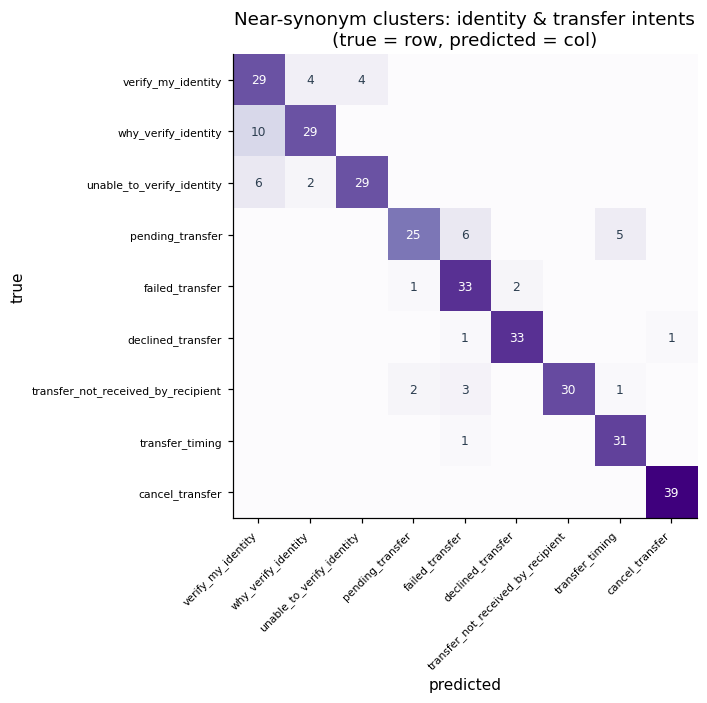

In [9]:
fam=[f for f in ["verify_my_identity","why_verify_identity","unable_to_verify_identity",
     "pending_transfer","failed_transfer","declined_transfer",
     "transfer_not_received_by_recipient","transfer_timing","cancel_transfer"] if f in labels]
sub=confusion_matrix(y,pred,labels=fam)
fig,ax=plt.subplots(figsize=(7.5,6.5)); im=ax.imshow(sub,cmap="Purples")
ax.set_xticks(range(len(fam))); ax.set_xticklabels(fam,rotation=45,ha="right",fontsize=7)
ax.set_yticks(range(len(fam))); ax.set_yticklabels(fam,fontsize=7)
for i in range(len(fam)):
    for j in range(len(fam)):
        if sub[i,j]: ax.text(j,i,sub[i,j],ha="center",va="center",color="white" if sub[i,j]>sub.max()*.5 else INK,fontsize=8)
ax.set_title("Near-synonym clusters: identity & transfer intents\n(true = row, predicted = col)")
ax.set_xlabel("predicted"); ax.set_ylabel("true")
plt.tight_layout(); plt.savefig(f"{VIZ}/10_intent_family_confusion.png"); plt.show()

**Read:** the three identity intents (`verify_my_identity` / `why_verify_identity` /
`unable_to_verify_identity`) bleed into each other, while a distinct intent like
`cancel_transfer` stays clean. When several labels describe the same underlying question,
a bag-of-words model has almost no signal to separate them. My take: this is as much a
**labelling-taxonomy** problem as a modelling one — and it's the clearest place to test
whether an LLM's semantic understanding actually helps.

## 6. Confidence & gating — why the automated stream can be trusted

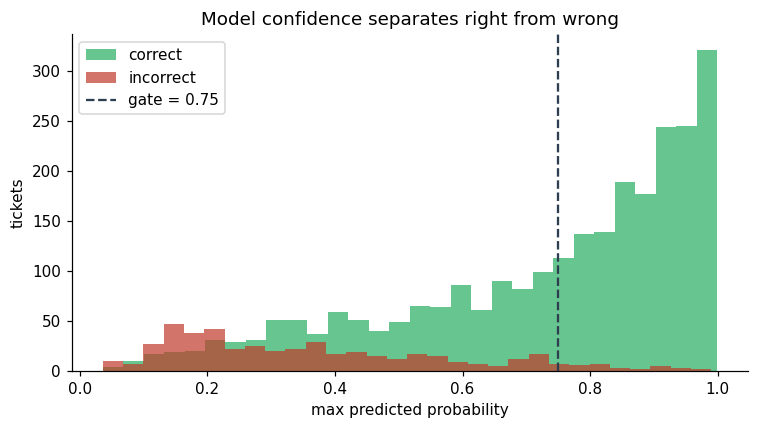

In [10]:
fig, ax = plt.subplots(figsize=(7,4))
ax.hist(conf[correct], bins=30, alpha=.7, color=GOOD, label="correct")
ax.hist(conf[~correct], bins=30, alpha=.7, color=BAD, label="incorrect")
ax.axvline(0.75, color=INK, ls="--", lw=1.5, label="gate = 0.75")
ax.set_title("Model confidence separates right from wrong"); ax.set_xlabel("max predicted probability"); ax.set_ylabel("tickets"); ax.legend()
plt.tight_layout(); plt.savefig(f"{VIZ}/05_baseline_confidence_distribution.png"); plt.show()

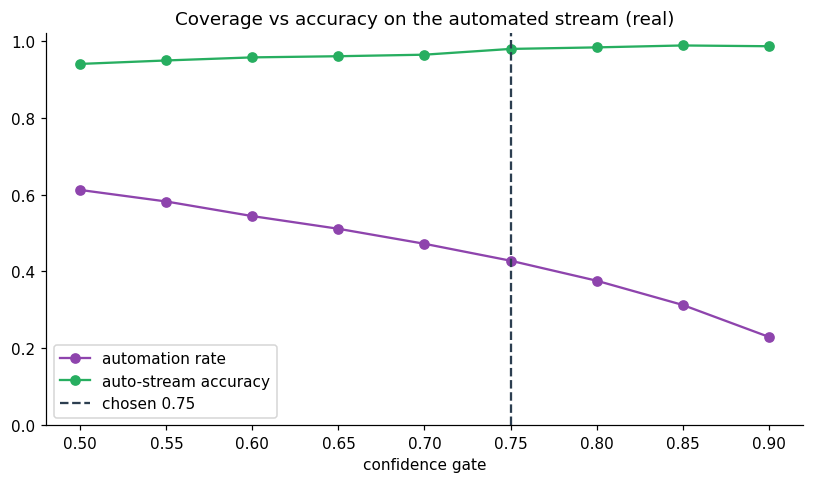

,threshold,automation_rate,auto_stream_acc,n_auto
0,0.50,0.612,0.940,1885
1,0.55,0.582,0.949,1791
2,0.60,0.544,0.957,1676
3,0.65,0.511,0.960,1575
4,0.70,0.472,0.964,1455
5,0.75,0.428,0.979,1318
6,0.80,0.376,0.983,1159
7,0.85,0.313,0.988,965
8,0.90,0.230,0.986,708


In [11]:
preds=[{"intent":pred[i],"confidence":float(conf[i])} for i in range(len(pred))]
rows=[]
for thr in [.5,.55,.6,.65,.7,.75,.8,.85,.9]:
    s=automation_summary(preds,conf_threshold=thr)
    idx=[k for k in range(len(pred)) if s["decisions"][k]=="auto"]
    rows.append({"threshold":thr,"automation_rate":round(s["automation_rate"],3),
                 "auto_stream_acc":round(accuracy_score(y[idx],pred[idx]),3) if idx else None,"n_auto":len(idx)})
sweep=pd.DataFrame(rows)
fig,ax=plt.subplots(figsize=(7.5,4.5))
ax.plot(sweep.threshold,sweep.automation_rate,"-o",color=ACCENT,label="automation rate")
ax.plot(sweep.threshold,sweep.auto_stream_acc,"-o",color=GOOD,label="auto-stream accuracy")
ax.axvline(.75,color=INK,ls="--",label="chosen 0.75"); ax.set_ylim(0,1.02); ax.set_xlabel("confidence gate"); ax.legend()
ax.set_title("Coverage vs accuracy on the automated stream (real)")
plt.tight_layout(); plt.savefig(f"{VIZ}/07_confidence_threshold_tradeoff.png"); plt.show()
sweep

## 7. High-stakes routing & the automation funnel

15 of the 77 intents (fraud, loss, security, money at risk) are never auto-resolved
when the model **predicts** them, whatever the confidence. They're listed in
`src/data_loader.py`. What that rule cannot do is measured in the audit below it.

High-stakes intents: 15
At the 0.75 gate: 42.8% auto-handled, 97.9% accurate on that stream.
High-stakes predictions routed to a human: 583


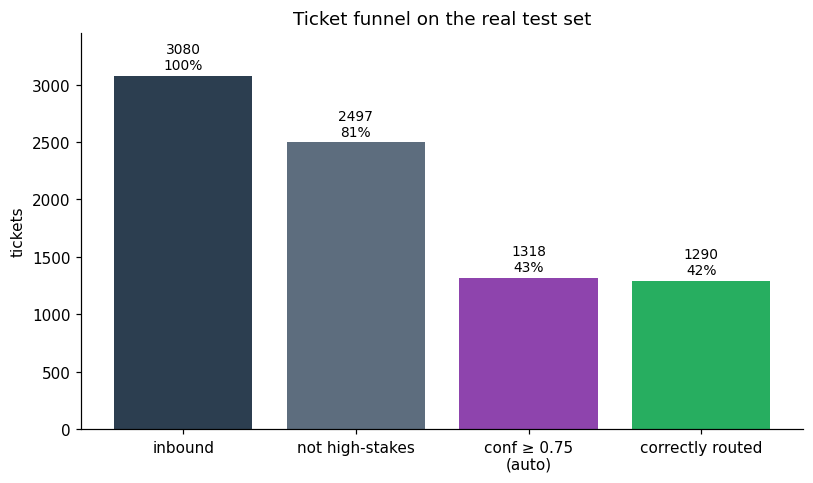

In [12]:
print("High-stakes intents:", len(HIGH_STAKES))
CHOSEN=0.75
s=automation_summary(preds,conf_threshold=CHOSEN)
auto_idx=[k for k in range(len(pred)) if s["decisions"][k]=="auto"]
auto_acc=accuracy_score(y[auto_idx],pred[auto_idx])
hs_pred=int(sum(1 for p in pred if p in HIGH_STAKES))
total=len(pred); not_hs=int(sum(1 for p in pred if p not in HIGH_STAKES)); auto=len(auto_idx); ok=int(round(auto*auto_acc))
print(f"At the 0.75 gate: {s['automation_rate']*100:.1f}% auto-handled, {auto_acc*100:.1f}% accurate on that stream.")
print(f"High-stakes predictions routed to a human: {hs_pred}")

fig,ax=plt.subplots(figsize=(7.5,4.5))
stages=["inbound","not high-stakes",f"conf ≥ {CHOSEN}\n(auto)","correctly routed"]; vals=[total,not_hs,auto,ok]
ax.bar(stages,vals,color=[INK,"#5d6d7e",ACCENT,GOOD])
for i,v in enumerate(vals): ax.text(i,v+total*.01,f"{v}\n{v/total*100:.0f}%",ha="center",va="bottom",fontsize=9)
ax.set_ylim(0,total*1.12); ax.set_ylabel("tickets"); ax.set_title("Ticket funnel on the real test set")
plt.tight_layout(); plt.savefig(f"{VIZ}/08_automation_funnel.png"); plt.show()

**What the gate does and does not guarantee.** The rule is applied to the
*predicted* intent, so it stops every ticket the model believes is high-stakes —
but it cannot stop one the model confidently believes is routine. Audited against
ground truth on the real test set: of **600** genuinely high-stakes tickets,
**2** were auto-handled — a **0.33%** leak of the high-stakes stream (0.06% of all
tickets). Both were plainly worded and unremarkable to a bag-of-words model:
*"I can't transfer money from my account."* (truly `declined_transfer`, predicted
`transfer_into_account` at 0.92) and *"My card was not accepted."* (truly
`declined_card_payment`, predicted `card_acceptance` at 0.80).

I tested the obvious mitigation — a keyword tripwire on the ticket text
(`stolen`, `fraud`, `declined`, `not recognised`, and ten more) — and **rejected
it**: it moved 11 tickets off the automated stream and caught **0 of the 2**
leaks, because neither message contains a risk word. That is the whole problem in
miniature — the tickets that slip through are exactly the ones whose *surface
text* looks routine, which is also why the model missed them and why it was
confident. Closing this properly needs the model's own uncertainty, not the
customer's vocabulary: gate on the union of the top-k predicted intents, or train
a recall-oriented second classifier that answers only "is this risky?" and let it
veto. Reported here rather than buried, because a guardrail's residual is the
number that decides whether ops can trust it.

## 8. The LLM triage engine — LIVE + an honest offline stub

The engine's job is broader than the baseline: one call returns intent, urgency, sentiment,
entities, and a draft reply. Here's the real system prompt and the output *shape*. The
offline stub below returns `intent=None` on purpose — on 77-way real text it is a keyword
heuristic, **not** a language model, so it is never scored as Claude.

In [13]:
print(build_system_prompt()[:600], "...\n")
sample = test[TEXT_COL].iloc[0]
print("Example ticket:", repr(sample))
out = classify_ticket(sample, force_offline=True)
print("Offline stub output (SHAPE only — intent deliberately None, not scored):")
print(json.dumps(out, indent=2))

You are an intent-triage assistant for a retail bank's customer support queue.
You read one inbound customer message and return a STRICT JSON object a routing
system will consume. Never add commentary outside the JSON.

Rules:
- intent MUST be exactly one of these 77 labels:
Refund_not_showing_up, activate_my_card, age_limit, apple_pay_or_google_pay, atm_support, automatic_top_up, balance_not_updated_after_bank_transfer, balance_not_updated_after_cheque_or_cash_deposit, beneficiary_not_allowed, cancel_transfer, card_about_to_expire, card_acceptance, card_arrival, card_delivery_estimate, card_l ...

Example ticket: 'How do I locate my card?'
Offline stub output (SHAPE only — intent deliberately None, not scored):
{
  "intent": null,
  "urgency": "medium",
  "sentiment": "neutral",
  "confidence": 0.0,
  "entities": {},
  "draft_reply": "Thanks for getting in touch \u2014 I can see what you're asking about and I'm looking into it now. I'll follow up shortly with the details and next step

In [14]:
# What running the real head-to-head would cost, and how it would run:
print("Cost estimate to score the full test set in LIVE mode:", estimate_live_cost(len(test)))
if is_live_mode():
    from src.llm_classifier import classify_batch
    sample_idx = test.sample(min(300,len(test)), random_state=0).index
    llm = classify_batch(test.loc[sample_idx, TEXT_COL].tolist())
    llm_pred = [o.get("intent") for o in llm]
    llm_acc = accuracy_score(test.loc[sample_idx, LABEL_COL], llm_pred)
    print(f"LIVE zero-shot Claude intent accuracy on {len(sample_idx)} sampled tickets: {llm_acc:.4f}")
    print(f"Trained baseline on the same tickets: {accuracy_score(y[[test.index.get_loc(i) for i in sample_idx]], pred[[test.index.get_loc(i) for i in sample_idx]]):.4f}")
else:
    print("\nNo ANTHROPIC_API_KEY set -> LLM head-to-head SKIPPED (not faked).")
    print("Set the key and re-run this cell to populate the real comparison.")

Cost estimate to score the full test set in LIVE mode: {'n_tickets': 3080, 'est_usd': 12.47}

No ANTHROPIC_API_KEY set -> LLM head-to-head SKIPPED (not faked).
Set the key and re-run this cell to populate the real comparison.


## 9. Capability coverage — one LLM call vs a trained classifier (conceptual)

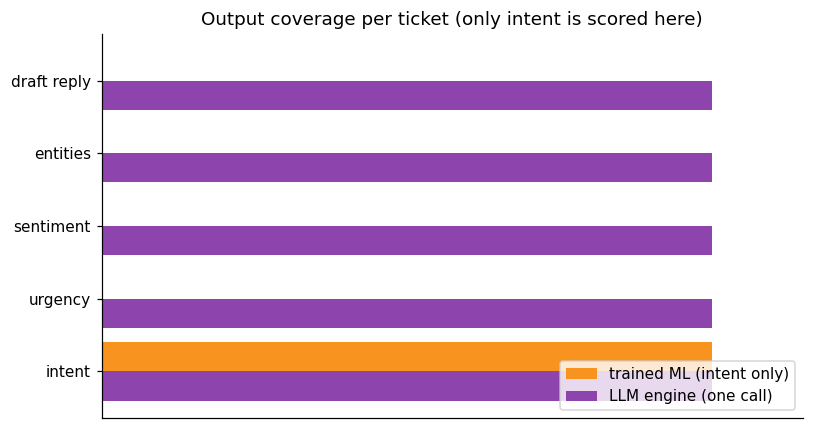

In [15]:
caps=["intent","urgency","sentiment","entities","draft reply"]; mlh=[1,0,0,0,0]; lh=[1,1,1,1,1]
fig,ax=plt.subplots(figsize=(7.5,4)); yy=np.arange(len(caps))
ax.barh(yy+.2,mlh,height=.4,color=ML,label="trained ML (intent only)")
ax.barh(yy-.2,lh,height=.4,color=ACCENT,label="LLM engine (one call)")
ax.set_yticks(yy); ax.set_yticklabels(caps); ax.set_xlim(0,1.15); ax.set_xticks([])
ax.set_title("Output coverage per ticket (only intent is scored here)"); ax.legend(loc="lower right")
plt.tight_layout(); plt.savefig(f"{VIZ}/06_capability_comparison.png"); plt.show()

## 10. Business ROI — *illustrative model*

The automation rate and routing accuracy are **real**. The dollar figures apply them to an
**assumed** 12,000-ticket/month volume — a framework to plug real inputs into, not banked savings.

{
  "annual_volume": 144000,
  "baseline_annual_cost": 691200.0,
  "engine_annual_cost": 428382.74,
  "net_annual_savings": 262817.26,
  "savings_pct": 0.3802,
  "agent_hours_freed": 8529.0,
  "llm_annual_cost": 1728.0,
  "rework_annual_cost": 8377.75,
  "auto_tickets": 61617,
  "human_tickets": 82382,
  "assumptions": {
    "monthly_volume": 12000,
    "minutes_per_ticket_manual": 9.0,
    "minutes_per_ticket_assisted": 2.5,
    "loaded_hourly_cost": 32.0,
    "llm_cost_per_ticket": 0.012,
    "rework_minutes_per_error": 12.0,
    "pretriage_time_saving": 0.15
  }
}


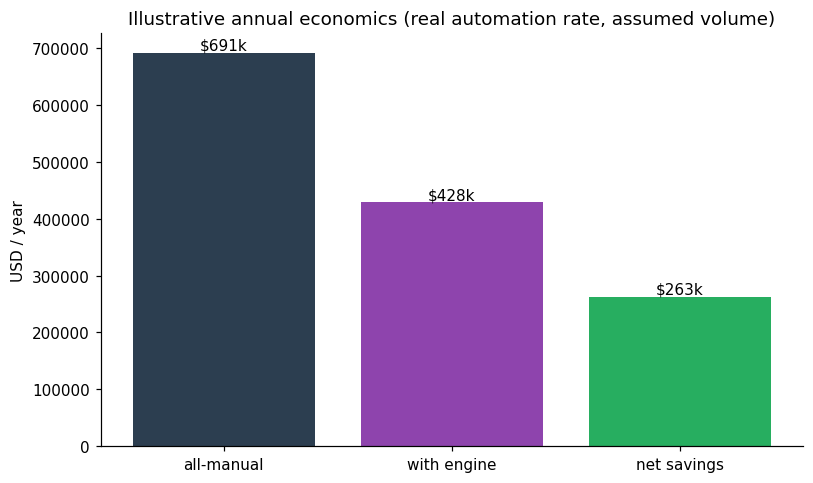

In [16]:
roi=roi_model(automation_rate=s["automation_rate"], auto_accuracy=auto_acc)
print(json.dumps(roi, indent=2))
fig,ax=plt.subplots(figsize=(7.5,4.5))
ax.bar(["all-manual"],[roi['baseline_annual_cost']],color=INK)
ax.bar(["with engine"],[roi['engine_annual_cost']],color=ACCENT)
ax.bar(["net savings"],[roi['net_annual_savings']],color=GOOD)
for i,v in enumerate([roi['baseline_annual_cost'],roi['engine_annual_cost'],roi['net_annual_savings']]):
    ax.text(i,v,f"${v/1000:.0f}k",ha="center",va="bottom")
ax.set_title("Illustrative annual economics (real automation rate, assumed volume)"); ax.set_ylabel("USD / year")
plt.tight_layout(); plt.savefig(f"{VIZ}/09_roi_waterfall.png"); plt.show()

## 11. Persist real metrics & predictions

In [17]:
from datetime import date
# Audit the gate against ground truth: high-stakes tickets the model
# confidently mislabelled as routine, which the gate therefore let through.
leak=high_stakes_leakage([{"true_intent":y[i],"intent":pred[i],"confidence":float(conf[i])}
                          for i in range(len(pred))], conf_threshold=CHOSEN)
top_conf=[{"true":t,"pred":p,"count":c} for c,t,p in pairs]
metrics={"generated_on":str(date.today()),"data_is_real":True,
 "dataset":{"name":DATASET_NAME,"source":DATASET_SOURCE,"license":DATASET_LICENSE,
            "n_train":len(train),"n_test":len(test),"n_intents":len(labels)},
 "baseline_ml":base,"top_confusions":top_conf,
 "gating":{"chosen_threshold":CHOSEN,"automation_rate":round(s["automation_rate"],4),
           "auto_stream_accuracy":round(float(auto_acc),4),"high_stakes_routed_to_human":hs_pred,
           "high_stakes_leakage":leak},
 "roi_illustrative":roi,
 "llm":{"status":"live" if is_live_mode() else "not_run_no_api_key",
        "scored_dimension":"intent only (BANKING77 has no urgency/sentiment/entity labels)",
        "note":"Offline stub is not a language model and is never scored as Claude. Set ANTHROPIC_API_KEY to run the head-to-head."}}
rep="../reports" if os.path.basename(os.getcwd())=="notebooks" else "reports"
proc="../data/processed" if os.path.basename(os.getcwd())=="notebooks" else "data/processed"
os.makedirs(proc, exist_ok=True)
json.dump(metrics, open(f"{rep}/triage_metrics.json","w"), indent=2)
out_df=test.copy(); out_df["pred_intent"]=pred; out_df["confidence"]=conf.round(4); out_df["correct"]=correct
out_df.to_csv(f"{proc}/test_predictions.csv", index=False)
print("Wrote reports/triage_metrics.json and data/processed/test_predictions.csv")

Wrote reports/triage_metrics.json and data/processed/test_predictions.csv


## 12. Conclusions & recommendation

**What the real data actually shows:**

- A plain **TF-IDF + Logistic Regression** model routes real banking tickets into 77
  fine-grained intents at **84.8% accuracy / 0.848 macro-F1**. On the routing task alone,
  the cheap trained model is a strong, hard-to-beat control.
- Its errors are **not random** — they concentrate in near-synonym clusters (the identity
  trio, transfer states, card-ordering siblings). I'd argue this is partly a
  **taxonomy** problem: several intents describe the same underlying question.
- With confidence gating at 0.75 and high-stakes intents always escalated, **42.8%** of
  tickets auto-handle at **97.9%** accuracy — a defensible operating point on real data.

**The open question — and the honest limitation of this build:** whether zero-shot Claude
beats the trained model on intent, *especially on those near-synonym clusters*, is **not
answered here** because no API key was available. I refused to fill that number in with the
offline stub. The LIVE path is built and one command from running.

**Recommendation:** ship the trained model for routing today — it's accurate, cheap, and
fast. Add the LLM for what the model structurally can't do (urgency, sentiment, drafts) and
point it first at the near-synonym confusions, then **measure** whether it actually wins
there before committing. Don't buy the AI on faith; make it earn the routing job against a
baseline that's already this good.

---
**Jordan Shamukiga — Data Analyst · Business Analyst · Data Scientist**
[GitHub](https://github.com/jordanshamu) · [Portfolio](https://datascienceportfol.io/jordanshamu)

*Data: BANKING77 (PolyAI, CC-BY-4.0). Trained-baseline numbers are real; the LLM head-to-head runs in LIVE mode.*